Device: cuda
Sample: p225_001_mic1.pt
Checkpoints found: 8

Rank by validation loss
epoch | train_loss | val_loss | sample_L1 | postnet_gain | pred_std/truth_std
    5 | 1.0903 | 0.6175 | 0.7221 | -0.0004 | 2.0519/2.0407
    6 | 1.0547 | 0.6251 | 0.8499 | +0.0000 | 2.0922/2.0407
    8 | 1.0380 | 0.6251 | 0.9360 | -0.0020 | 2.0970/2.0407
    7 | 1.0393 | 0.6283 | 0.8363 | +0.0012 | 1.9480/2.0407
    4 | 1.1362 | 0.6299 | 0.7915 | -0.0014 | 1.8709/2.0407
    3 | 1.2076 | 0.6474 | 1.0062 | -0.0008 | 2.1075/2.0407
    2 | 1.3369 | 0.6859 | 0.9276 | +0.0013 | 2.0609/2.0407
    1 | 1.9020 | 0.7591 | 1.0527 | -0.0054 | 2.2080/2.0407

Best checkpoint by validation loss: model_checkpoints\decoder_postnet_epoch_0005.pt
Best epoch: 5
Best validation loss: 0.6175
Fixed-sample mean L1: 0.7221
Fixed-sample median L1: 0.5740
Coarse mean L1 on sample: 0.7217
PostNet gain on sample: -0.0004


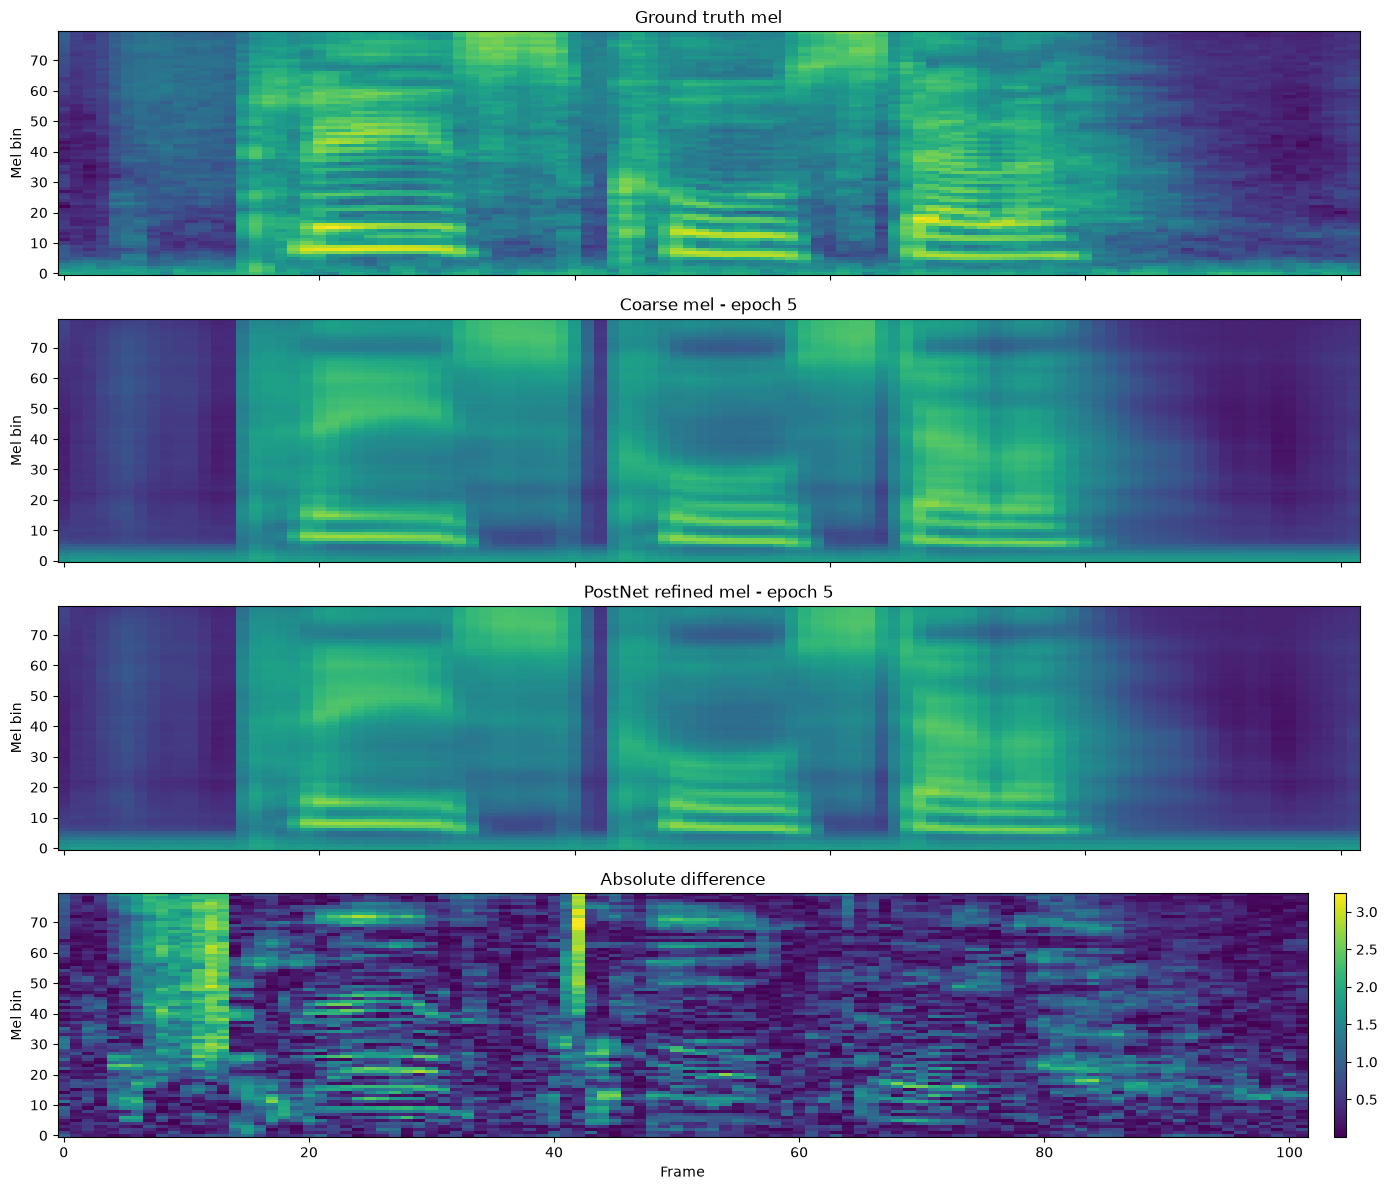

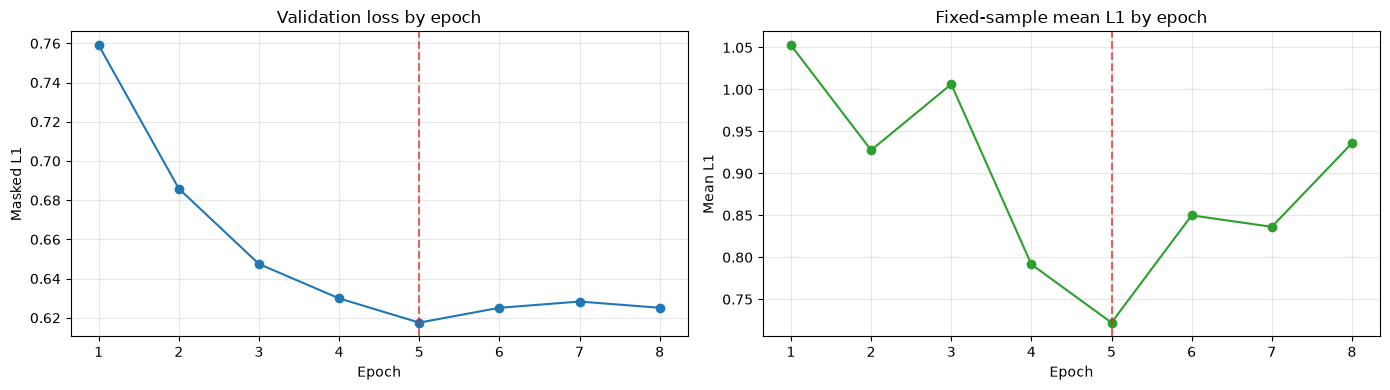

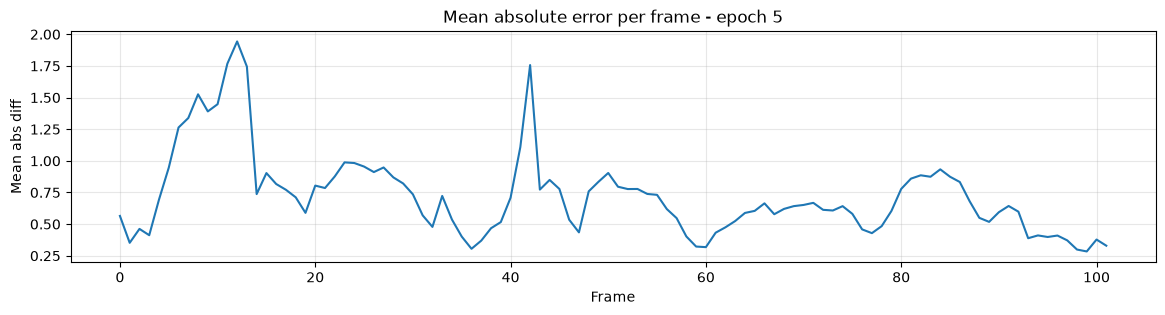

In [2]:
from pathlib import Path

import math



import matplotlib.pyplot as plt

import torch



from decoder_postnet import VCPostNetDecoder

from prepared_datasets.vc_dataset import load_content_latent, squeeze_content, squeeze_mel, squeeze_speaker



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_paths = sorted(Path("model_checkpoints").glob("decoder_postnet_epoch_*.pt"))

sample_id = "p225_001_mic1.pt"

truth_mel_path = Path("datasets/precomputed/mels") / sample_id

content_latent_path = Path("datasets/precomputed/contents") / sample_id

speaker_latent_path = Path("datasets/precomputed/speakers") / sample_id



if not checkpoint_paths:

    raise FileNotFoundError("No decoder_postnet_epoch_*.pt checkpoints found in model_checkpoints/.")



content_payload = torch.load(content_latent_path, map_location="cpu")

speaker_payload = torch.load(speaker_latent_path, map_location="cpu")

truth_payload = torch.load(truth_mel_path, map_location="cpu")



content = squeeze_content(load_content_latent(content_payload, sample_id)).unsqueeze(0).to(device)

speaker = squeeze_speaker(speaker_payload["speaker_latent"]).unsqueeze(0).to(device)

truth_mel_device = squeeze_mel(truth_payload["mel"]).to(device)



results = []

best_payload = None



for checkpoint_path in checkpoint_paths:

    checkpoint = torch.load(checkpoint_path, map_location=device)

    decoder = VCPostNetDecoder().to(device)

    decoder.load_state_dict(checkpoint["model_state_dict"])

    decoder.eval()



    with torch.no_grad():

        coarse_mel, pred_mel = decoder(content, speaker, return_coarse=True)

        coarse_mel = coarse_mel.squeeze(0)

        pred_mel = pred_mel.squeeze(0)



    time_steps = min(pred_mel.size(0), truth_mel_device.size(0))

    coarse_mel = coarse_mel[:time_steps]

    pred_mel = pred_mel[:time_steps]

    truth_mel = truth_mel_device[:time_steps]

    abs_diff = (pred_mel - truth_mel).abs()

    coarse_abs_diff = (coarse_mel - truth_mel).abs()



    result = {

        "checkpoint_path": checkpoint_path,

        "epoch": int(checkpoint.get("epoch", 0)),

        "train_loss": checkpoint.get("train_loss"),

        "val_loss": checkpoint.get("val_loss"),

        "sample_mean_l1": abs_diff.mean().item(),

        "sample_median_l1": abs_diff.median().item(),

        "coarse_sample_mean_l1": coarse_abs_diff.mean().item(),

        "postnet_gain": coarse_abs_diff.mean().item() - abs_diff.mean().item(),

        "pred_std": pred_mel.std().item(),

        "truth_std": truth_mel.std().item(),

    }

    results.append(result)



    if best_payload is None or result["val_loss"] < best_payload["result"]["val_loss"]:

        best_payload = {

            "result": result,

            "coarse_mel": coarse_mel.detach().cpu(),

            "pred_mel": pred_mel.detach().cpu(),

            "truth_mel": truth_mel.detach().cpu(),

            "abs_diff": abs_diff.detach().cpu(),

        }



results_by_val = sorted(results, key=lambda item: item["val_loss"] if item["val_loss"] is not None else math.inf)

best = best_payload["result"]



print(f"Device: {device}")

print(f"Sample: {sample_id}")

print(f"Checkpoints found: {len(checkpoint_paths)}")

print()

print("Rank by validation loss")

print("epoch | train_loss | val_loss | sample_L1 | postnet_gain | pred_std/truth_std")

for item in results_by_val:

    print(

        f"{item['epoch']:>5} | "

        f"{item['train_loss']:.4f} | "

        f"{item['val_loss']:.4f} | "

        f"{item['sample_mean_l1']:.4f} | "

        f"{item['postnet_gain']:+.4f} | "

        f"{item['pred_std']:.4f}/{item['truth_std']:.4f}"

    )



print()

print(f"Best checkpoint by validation loss: {best['checkpoint_path']}")

print(f"Best epoch: {best['epoch']}")

print(f"Best validation loss: {best['val_loss']:.4f}")

print(f"Fixed-sample mean L1: {best['sample_mean_l1']:.4f}")

print(f"Fixed-sample median L1: {best['sample_median_l1']:.4f}")

print(f"Coarse mean L1 on sample: {best['coarse_sample_mean_l1']:.4f}")

print(f"PostNet gain on sample: {best['postnet_gain']:+.4f}")



truth_mel = best_payload["truth_mel"]

coarse_mel = best_payload["coarse_mel"]

pred_mel = best_payload["pred_mel"]

abs_diff = best_payload["abs_diff"]



vmin = min(truth_mel.min().item(), coarse_mel.min().item(), pred_mel.min().item())

vmax = max(truth_mel.max().item(), coarse_mel.max().item(), pred_mel.max().item())



fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].imshow(truth_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)

axes[0].set_title("Ground truth mel")

axes[0].set_ylabel("Mel bin")



axes[1].imshow(coarse_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)

axes[1].set_title(f"Coarse mel - epoch {best['epoch']}")

axes[1].set_ylabel("Mel bin")



axes[2].imshow(pred_mel.T, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)

axes[2].set_title(f"PostNet refined mel - epoch {best['epoch']}")

axes[2].set_ylabel("Mel bin")



diff_image = axes[3].imshow(abs_diff.T, aspect="auto", origin="lower")

axes[3].set_title("Absolute difference")

axes[3].set_xlabel("Frame")

axes[3].set_ylabel("Mel bin")

fig.colorbar(diff_image, ax=axes[3], fraction=0.02, pad=0.02)

plt.tight_layout()

plt.show()



epochs = [item["epoch"] for item in results]

val_losses = [item["val_loss"] for item in results]

sample_losses = [item["sample_mean_l1"] for item in results]



fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, val_losses, marker="o")

axes[0].axvline(best["epoch"], color="tab:red", linestyle="--", alpha=0.7)

axes[0].set_title("Validation loss by epoch")

axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("Masked L1")

axes[0].grid(alpha=0.3)



axes[1].plot(epochs, sample_losses, marker="o", color="tab:green")

axes[1].axvline(best["epoch"], color="tab:red", linestyle="--", alpha=0.7)

axes[1].set_title("Fixed-sample mean L1 by epoch")

axes[1].set_xlabel("Epoch")

axes[1].set_ylabel("Mean L1")

axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()



plt.figure(figsize=(14, 3))

plt.plot(abs_diff.mean(dim=1))

plt.title(f"Mean absolute error per frame - epoch {best['epoch']}")

plt.xlabel("Frame")

plt.ylabel("Mean abs diff")

plt.grid(alpha=0.3)

plt.show()
